In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Predicting Daily Biogas Production Using Machine Learning

## 1. Research problem
### 1.1. Background

Biogas production from organic waste plays an important role in sustainable energy generation and waste management. The ability to accurately predict daily biogas output enables better planning of energy supply and optimization of the anaerobic digestion process. This project uses a 15-year representing dataset from a biogas plant in India to develop regression models capable of predicting daily biogas production and supporting operational decision-making in similar facilities.

### 1.2 Business Perspective

Can daily biogas production (m³) be predicted from feedstock composition, operational parameters, and environmental conditions with sufficient accuracy to support the operation and planning of a biogas plant?

### 1.3 Data science Perspective
Build regression model that predicts continous value of Raw Biogas Produced (m³) using 25 scalar values. Model will be evaluated base on R² and RMSE where a good values will be considered R^2 > 0.75 and RMSE < 10% for mean biogas production.
Why these values? 0.75 will show a good 

For a biogas plant prediction of 10% error is acceptable because the gas storage buffer absorbs the daily fluctuations. According to the literature gasholders are designed as buffer devices that adjust peaks and fluctuations in biogas production.<sup>[1]</sup> The typical storage production is 10-30% of the daily production for continuously operating systems. A prediction error of 10% falls into this range, which means that the plant can absorb such a deviation without operation disturbance.  

#### 1.4. Hypothesis

A machine learning model can predict daily biogas production from feedstock composition, environmental conditions, and operational parameters with useful accuracy (R² > 0.75).

## 2. Hypothesis - reconsider
Null hypothesis (H₀)

The available input variables (waste composition, operational parameters, and weather conditions) do not provide meaningful predictive information about daily biogas production.

Any prediction model will perform no better than a simple baseline using the average daily production.

Feedstock quantities, biological process parameters, and environmental conditions are not associated with daily biogas production.

Alternative hypothesis (H₁)

Feedstock quantities, biological process parameters, and environmental conditions are not associated with daily biogas production. Specifically, higher quantities of organic feedstock and favorable digestion conditions are expected to increase biogas production.

A regression model trained on these variables will significantly outperform a baseline model. 
We expect:

* Models using waste composition, operational parameters, and weather conditions to outperform a baseline model.
* Waste quantity variables to show a positive relationship with biogas production.
* Feature importance analysis to identify waste composition as one of the key drivers of production.

The hypothesis will be considered supported if:

* the final model achieves R² ≥ 0.75;
* RMSE remains below 10% of the mean daily production;
* models including waste-related features perform substantially better than models using weather variables alone.

Summary:
We expect tree-based ensemble models (Random Forest and Gradient Boosting) to outperform a simple linear regression baseline because biogas production is influenced by multiple interacting process and environmental variables.


## 2. Dataset Overview
The dataset contains 25 operational data from a biogas plant, including feedstock quantities, environmental conditions, and process-related variables.

## Feature Categories

| Category | Examples |

|-----------|----------|

| Feedstock | Pig Manure, Kitchen Food Waste, Chicken Litter, Fish Waste |

| Operational | Water Usage, Diesel Consumption, Electricity Usage |

| Environmental | Temperature, Humidity, Rainfall |

| Process Variables | Digester Temperature, C/N Ratio |

| Target | biogas_production |

Explaination of the features

Based on domain knowledge of anaerobic digestion, several variables in the dataset are known to influence biogas production.:

* Feedstock Composition: Kitchen food waste, Pig manure, Chicken litter
* Volatile solids
* Digester temperature
* Hydraulic retention time (HRT)
* C/N ratio

*Technical Background*

**Feedstock Composition**

Biogas is produced through anaerobic digestion of organic materials. Feedstocks such as kitchen food waste, pig manure, chicken litter, and municipal residues provide the organic matter that microorganisms convert into biogas. In general, larger quantities of biodegradable material are expected to increase gas production.

**Volatile Solids (VS)**

Volatile solids represent the biodegradable portion of the feedstock. Since microorganisms consume this organic matter during digestion, higher volatile solids content is generally associated with greater biogas production potential.

**Digester Temperature**

Microbial activity depends strongly on temperature. Digestion is most efficient within specific temperature ranges, while lower temperatures can reduce gas production by slowing microbial processes.

**Hydraulic Retention Time (HRT)**

Hydraulic Retention Time measures how long the feedstock remains inside the digester. Longer retention times allow microorganisms more time to break down organic material and produce biogas.

**Carbon-to-Nitrogen Ratio (C/N Ratio)**

The C/N ratio describes the balance between carbon and nitrogen in the feedstock. An appropriate balance supports microbial growth and efficient digestion, while an imbalance may reduce biogas yield.

## Dataset Structure


In [4]:
biogas_data = pd.read_csv('biogas_dataset.csv')
biogas_data.shape
biogas_data.head()
biogas_data.info()
biogas_data.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 15298 entries, 0 to 15297
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     15298 non-null  int64  
 1   Month                    15298 non-null  int64  
 2   Day                      15298 non-null  int64  
 3   Pig Manure (kg)          15298 non-null  float64
 4   Kitchen Food Waste (kg)  15298 non-null  float64
 5   Chicken Litter (kg)      15298 non-null  float64
 6   Cassava (kg)             15298 non-null  float64
 7   Bagasse Feed (kg)        15298 non-null  float64
 8   Energy Grass (kg)        15298 non-null  float64
 9   Banana Shafts (kg)       15298 non-null  float64
 10  Alcohol Waste (kg)       15298 non-null  float64
 11  Municipal Residue (kg)   15298 non-null  float64
 12  Fish Waste (kg)          15298 non-null  float64
 13  Water (L)                15298 non-null  float64
 14  Diesel (L)               15298 no

Year                         int64
Month                        int64
Day                          int64
Pig Manure (kg)            float64
Kitchen Food Waste (kg)    float64
Chicken Litter (kg)        float64
Cassava (kg)               float64
Bagasse Feed (kg)          float64
Energy Grass (kg)          float64
Banana Shafts (kg)         float64
Alcohol Waste (kg)         float64
Municipal Residue (kg)     float64
Fish Waste (kg)            float64
Water (L)                  float64
Diesel (L)                 float64
Electricity Use (kWh)      float64
Temperature (C)            float64
Humidity (%)               float64
Rainfall (mm)              float64
C/N Ratio                  float64
Digester Temp (C)          float64
biogas_production          float64
dtype: object

### Initial Observations

Dataset contains 15,298 observations. All variables are numerical (`int64` or `float64`). No categorical variables are present. The target variable is `biogas_production`.

# 4. Data Quality Assessment

In [13]:
print(biogas_data.isnull().sum())
print(f"Duplicates: {biogas_data.duplicated().sum()}")

Year                       0
Month                      0
Day                        0
Pig Manure (kg)            0
Kitchen Food Waste (kg)    0
Chicken Litter (kg)        0
Cassava (kg)               0
Bagasse Feed (kg)          0
Energy Grass (kg)          0
Banana Shafts (kg)         0
Alcohol Waste (kg)         0
Municipal Residue (kg)     0
Fish Waste (kg)            0
Water (L)                  0
Diesel (L)                 0
Electricity Use (kWh)      0
Temperature (C)            0
Humidity (%)               0
Rainfall (mm)              0
C/N Ratio                  0
Digester Temp (C)          0
biogas_production          0
dtype: int64
Duplicates: 0


In [15]:
biogas_data.dtypes

Year                         int64
Month                        int64
Day                          int64
Pig Manure (kg)            float64
Kitchen Food Waste (kg)    float64
Chicken Litter (kg)        float64
Cassava (kg)               float64
Bagasse Feed (kg)          float64
Energy Grass (kg)          float64
Banana Shafts (kg)         float64
Alcohol Waste (kg)         float64
Municipal Residue (kg)     float64
Fish Waste (kg)            float64
Water (L)                  float64
Diesel (L)                 float64
Electricity Use (kWh)      float64
Temperature (C)            float64
Humidity (%)               float64
Rainfall (mm)              float64
C/N Ratio                  float64
Digester Temp (C)          float64
biogas_production          float64
dtype: object

### Findings
No missing values or duplicate records were identified in the dataset. All features are stored as numerical values and are suitable for regression analysis.
No categorical features are present, therefore no encoding techniques are required.

# 5. Exploratory Data Analysis (EDA)

## 5.1 Summary Statistics


In [19]:
biogas_data['biogas_production'].describe()

count    15298.000000
mean        79.211060
std         11.257695
min         41.937317
25%         71.296262
50%         78.816460
75%         86.707223
max        121.740430
Name: biogas_production, dtype: float64

In [17]:
biogas_data['biogas_production'].skew()

np.float64(0.18553199353932806)

Daily biogas production ranged from 41.9 m³ to 121.7 m³, with a mean of 79.2 m³ and a median of 78.8 m³. The small difference between the mean and median, together with a skewness value of 0.19, indicates an approximately symmetric distribution. The interquartile range (71.3–86.7 m³) shows that most observations are concentrated around the central tendency, suggesting relatively stable production levels with no obvious extreme anomalies.

* Are there outliers?

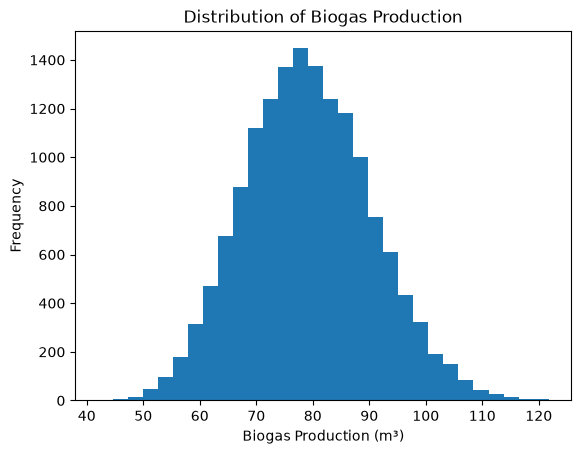

In [22]:
plt.hist(biogas_data["biogas_production"], bins=30)
plt.title("Distribution of Biogas Production")
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Frequency")
plt.show()

The distribution of daily biogas production appears  bell-shaped with a single peak, the histogram contains a single dominant peak, no strong skewness (skewness is approximately 0.19, indicating only slight positive skewness.): all these findings suggest a relatively stable production process without obvious subgroups or extreme asymmetry in the target variable.
## 5.3 Outlier Investigation